In [1]:
# 03 - Decision Tree Classifier on Diabetes Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score,
    classification_report, precision_score, recall_score, f1_score)

In [3]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv('datasets/diabetes.csv', header=None, names=col_names)
print("Shape:", data.shape)
print(data.head())

Shape: (768, 9)
   pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  label
0         6      148  72    35        0  33.6     0.627   50      1
1         1       85  66    29        0  26.6     0.351   31      0
2         8      183  64     0        0  23.3     0.672   32      1
3         1       89  66    23       94  28.1     0.167   21      0
4         0      137  40    35      168  43.1     2.288   33      1


In [4]:
print("Null values:")
print(data.isnull().sum())

Null values:
pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64


In [5]:
feature_cols = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
               'bmi', 'pedigree', 'age']
X = data[feature_cols]
y = data['label']

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (768, 8) y shape: (768,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (614, 8) Test: (154, 8)


In [7]:
model = DecisionTreeClassifier(criterion='entropy', random_state=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("First 20 predictions:", y_pred[:20])
print("First 20 actual     :", y_test.values[:20])

First 20 predictions: [1 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 1 0]
First 20 actual     : [0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0]


In [8]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[74 26]
 [26 28]]
Accuracy : 0.6623376623376623
Precision: 0.5185185185185185
Recall   : 0.5185185185185185
F1 Score : 0.5185185185185185

              precision    recall  f1-score   support

           0       0.74      0.74      0.74       100
           1       0.52      0.52      0.52        54

    accuracy                           0.66       154
   macro avg       0.63      0.63      0.63       154
weighted avg       0.66      0.66      0.66       154



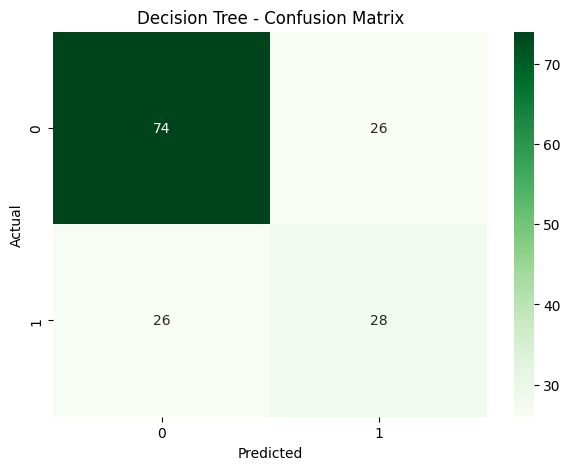

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

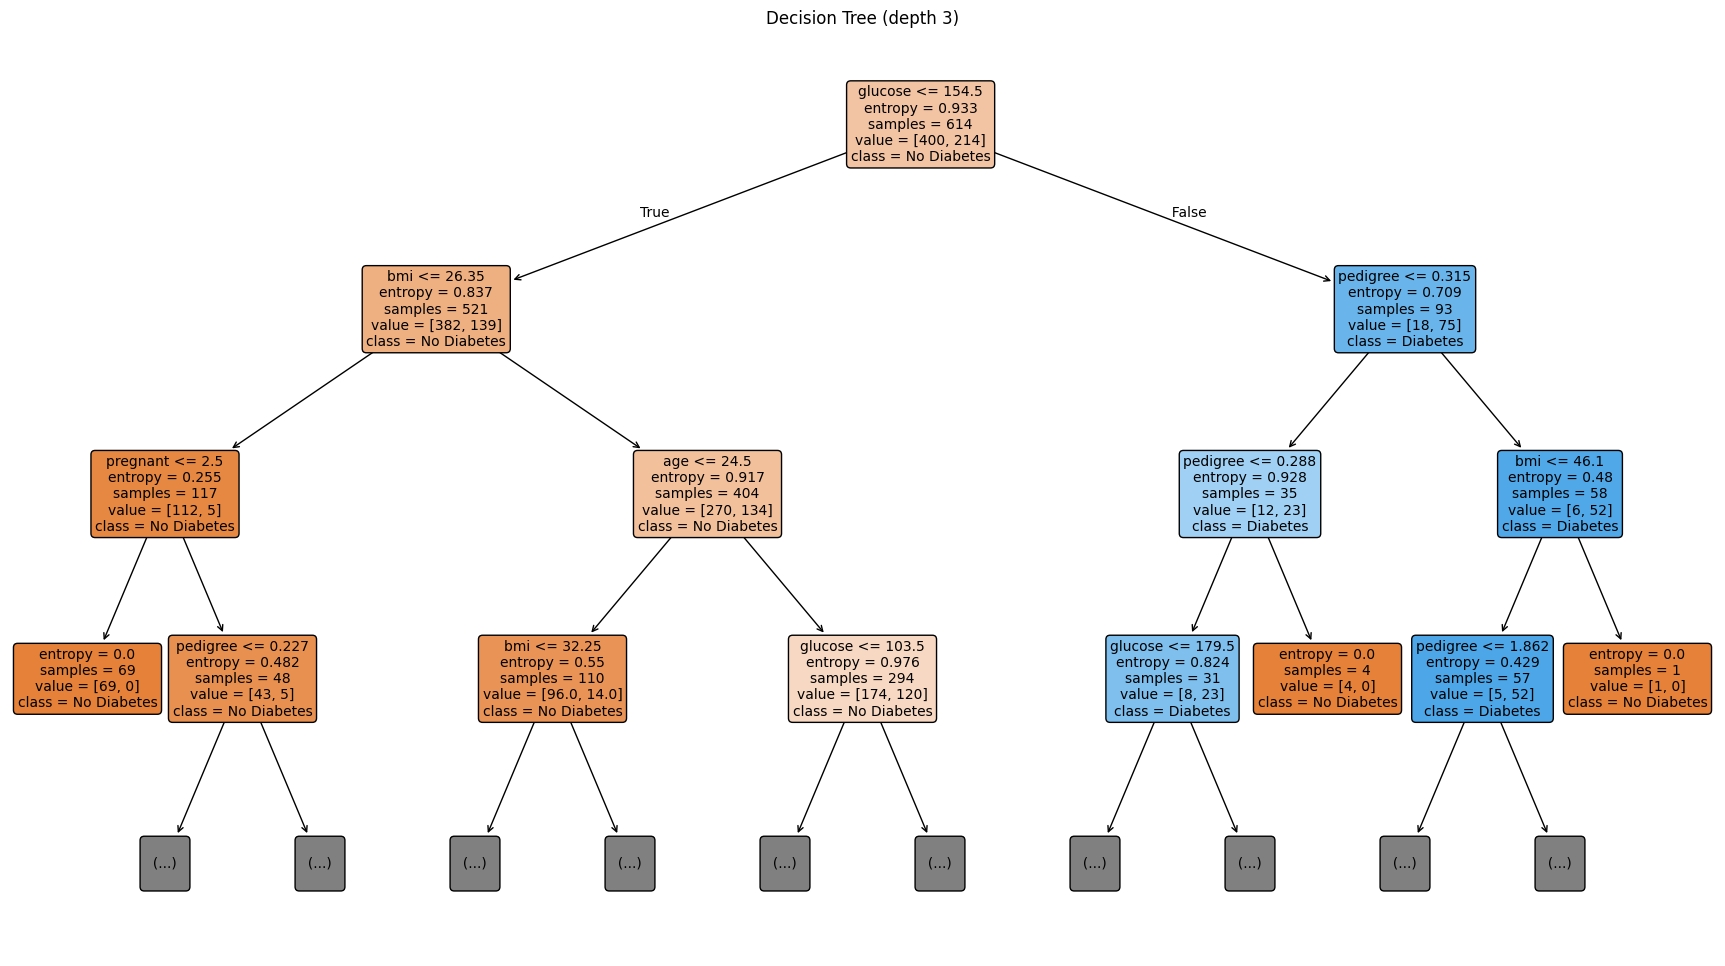

Tree depth: 25
Leaves    : 114


In [10]:
plt.figure(figsize=(22, 12))
plot_tree(model, feature_names=feature_cols,
          class_names=['No Diabetes', 'Diabetes'],
          filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title('Decision Tree (depth 3)')
plt.show()

print("Tree depth:", model.get_depth())
print("Leaves    :", model.get_n_leaves())

    Feature  Importance
1   glucose    0.278072
6  pedigree    0.159001
5       bmi    0.150096
7       age    0.144867
2        bp    0.096533
0  pregnant    0.062303
4   insulin    0.058222
3      skin    0.050906


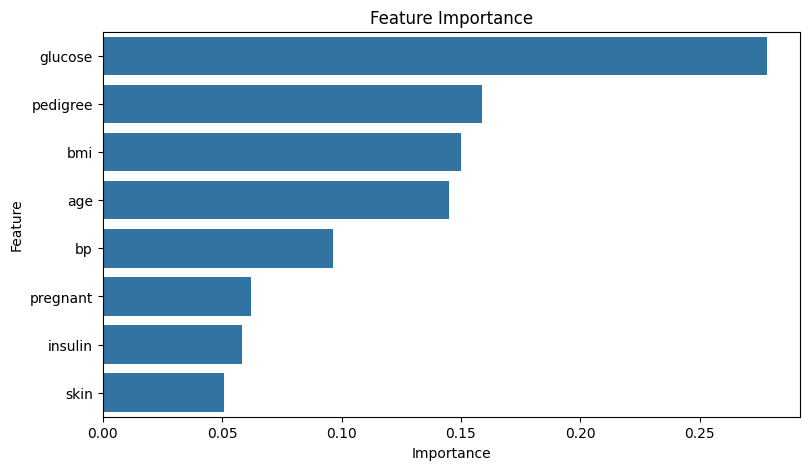

In [11]:
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_,
}).sort_values('Importance', ascending=False)
print(importance)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance')
plt.show()

In [12]:
model_gini = DecisionTreeClassifier(criterion='gini', random_state=5)
model_gini.fit(X_train, y_train)
y_pred_gini = model_gini.predict(X_test)

comparison = pd.DataFrame({
    'Criterion': ['Entropy', 'Gini'],
    'Accuracy' : [accuracy_score(y_test, y_pred),
                   accuracy_score(y_test, y_pred_gini)],
})
print(comparison)

  Criterion  Accuracy
0   Entropy  0.662338
1      Gini  0.675325


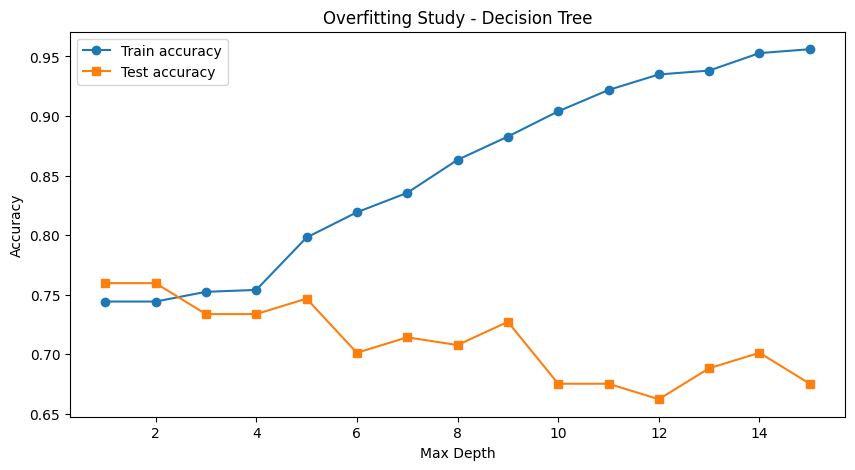

In [13]:
train_acc, test_acc = [], []
depths = range(1, 16)
for d in depths:
    t = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=5)
    t.fit(X_train, y_train)
    train_acc.append(t.score(X_train, y_train))
    test_acc.append(t.score(X_test,  y_test))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_acc, 'o-', label='Train accuracy')
plt.plot(depths, test_acc,  's-', label='Test accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Study - Decision Tree')
plt.legend()
plt.show()